<h1>SPTech — Análise de Dados</h1>
<h1>EDA — Análise Exploratória de Dados</h1>

Este notebook executa um roteiro completo de EDA sobre **qualquer base tabular**.

Para usar na base do seu Projeto de Inovação, altere **apenas a célula de configuração** logo abaixo e execute tudo (`Executar tudo` / `Run all`). Nenhuma outra célula precisa ser editada.

O roteiro segue a ordem apresentada na Aula 6:

| Seção | Conteúdo |
| --- | --- |
| 0 | Configuração e carga |
| 1 | Estrutura, grão e chave |
| 2 | Qualidade: nulos, nulos disfarçados, duplicatas |
| 3 | Univariada numérica: centro, dispersão, forma, extremos |
| 4 | Univariada categórica: frequência, cardinalidade, cauda longa |
| 5 | Outliers: IQR, z-score e z-score modificado |
| 6 | Séries temporais: tendência, sazonalidade, quebras |
| 7 | Bivariada: o gráfico certo para cada par de tipos |
| 8 | Correlação: Pearson, Spearman e o alerta de Anscombe |
| 9 | Segmentação com o n ao lado |
| 10 | Multivariada: facetas, confundimento e teste de Simpson |
| 11 | Síntese: achados, hipóteses e decisões |

---

# 0) Configuração

**Esta é a única célula que você precisa alterar.**

Preencha o caminho do arquivo e, se quiser, indique as colunas que têm papel especial. Tudo o que ficar vazio é detectado automaticamente.

In [1]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURAÇÃO — altere apenas esta célula
# ═══════════════════════════════════════════════════════════════════

CAMINHO  = "../data/base_eda_ingles.csv"
SEP      = ";"
ENCODING = "latin1"
DECIMAL  = "."

COLS_DATA    = ["dh_partida_real"]
COL_ALVO     = "nm_pais_destino"
COLS_IGNORAR = ["id_combinada", "sg_empresa_icao", "nr_voo",
                "sg_icao_origem", "sg_icao_destino",
                "nr_etapa", "nr_escala_destino"]
GRAO         = ["sg_empresa_icao", "nr_voo", "dh_partida_real",
                "sg_icao_origem", "sg_icao_destino", "ds_cotran"]
# Valores que devem ser lidos como ausentes
NA_EXTRA = ["", "-", "--", "N/A", "NA", "n/a", "não informado",
            "nao informado", "sem dado", "null", "NULL", "?", "#N/D"]

# Ajustes de exibição
MAX_CATEGORIAS  = 15      # categorias mostradas nos gráficos de barras
MIN_N_SEGMENTO  = 30      # n mínimo para um segmento ser considerado confiável
# ═══════════════════════════════════════════════════════════════════

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12

print("Bibliotecas carregadas. Pandas", pd.__version__)

Bibliotecas carregadas. Pandas 3.0.6


## 0.1) Carga

A leitura é feita **com tudo como texto**, como vimos na Aula 5: a conversão de tipos é decisão nossa, não palpite da biblioteca. A conversão acontece na célula seguinte, e o que não converter fica registrado.

In [3]:
df_bruto = pd.read_csv(
    CAMINHO,
    sep=SEP,
    encoding=ENCODING,
    dtype=str,
    na_values=NA_EXTRA,
    keep_default_na=True,
)

print(f"Arquivo: {CAMINHO}")
print(f"Linhas: {df_bruto.shape[0]:,}   Colunas: {df_bruto.shape[1]}".replace(",", "."))
df_bruto.head()

Arquivo: ../data/base_eda_ingles.csv
Linhas: 36.412   Colunas: 24


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino
0,93722735,CLX,6225,01/02/2025 06:51:00,SBKP,KMIA,NaN,2,5,0,0,0,0,0,0,0,CARGOLUX AIRLINES INTERNATIONAL S/A,ESTRANGEIRA REGULAR,NÃO REGULAR,NÃO IDENTIFICADO,CAMPINAS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
1,93722743,CLX,6225,01/02/2025 09:48:00,SBCT,KMIA,NaN,3,5,0,0,0,0,0,0,0,CARGOLUX AIRLINES INTERNATIONAL S/A,ESTRANGEIRA REGULAR,NÃO REGULAR,NÃO IDENTIFICADO,SÃO JOSÉ DOS PINHAIS,PR,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
2,93417447,FDX,0041,14/01/2025 16:44:00,SBKP,KMEM,NaN,1,2,0,0,0,21727,0,0,0,FEDEX - FEDERAL EXPRESS CORPORATION,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,CAMPINAS,SP,"MEMPHIS, TENNESSEE",ESTADOS UNIDOS DA AMÉRICA
3,93417449,FDX,0041,15/01/2025 17:22:00,SBKP,KMEM,NaN,1,2,0,0,0,32129,0,0,0,FEDEX - FEDERAL EXPRESS CORPORATION,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,CAMPINAS,SP,"MEMPHIS, TENNESSEE",ESTADOS UNIDOS DA AMÉRICA
4,93504496,LTG,8420,29/01/2025 17:27:00,SBKP,KMIA,CONEXÃO INTERNACIONAL,1,3,0,0,0,0,0,0,0,ABSA - AEROLINHAS BRASILEIRAS S.A.,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,CARGUEIRO,CAMPINAS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA


## 0.2) Conversão de tipos

Cada coluna é testada: se a maior parte dos valores válidos converte para número, ela vira numérica; se converte para data, vira datetime; caso contrário permanece como texto.

O relatório mostra **quanto se perdeu** em cada conversão. Perda alta é sinal de que a coluna precisa de limpeza antes, não de conversão.

In [4]:
import re

def tenta_numero(serie, decimal=DECIMAL):
    """Converte para número tratando separador decimal e de milhar.

    O separador de milhar só é removido quando está em posição de milhar
    (seguido de exatamente três dígitos). Isso evita que "999.0" vire 9990
    numa base configurada com decimal vírgula.
    """
    s = serie.astype(str).str.strip()
    if decimal == ",":
        s = s.str.replace(r"\.(?=\d{3}(\D|$))", "", regex=True)
        s = s.str.replace(",", ".", regex=False)
    else:
        s = s.str.replace(r",(?=\d{3}(\D|$))", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def tenta_data(serie):
    return pd.to_datetime(serie, errors="coerce", dayfirst=True)


df = df_bruto.copy()
relatorio_conversao = []

for col in df.columns:
    validos = df[col].notna().sum()
    if validos == 0:
        relatorio_conversao.append([col, "vazia", 0, 0.0])
        continue

    if col in COLS_DATA:
        conv = tenta_data(df[col])
        df[col] = conv
        perda = (df_bruto[col].notna() & conv.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    num = tenta_numero(df[col])
    taxa_num = num.notna().sum() / validos

    if taxa_num >= 0.90:
        df[col] = num
        perda = (df_bruto[col].notna() & num.isna()).sum()
        relatorio_conversao.append([col, "numérica", validos, round(perda / validos * 100, 1)])
        continue

    dat = tenta_data(df[col])
    if dat.notna().sum() / validos >= 0.90:
        df[col] = dat
        perda = (df_bruto[col].notna() & dat.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    relatorio_conversao.append([col, "texto", validos, 0.0])

rel_conv = pd.DataFrame(relatorio_conversao,
                        columns=["coluna", "tipo_final", "validos", "perda_pct"])
rel_conv.sort_values("perda_pct", ascending=False).head(20)

,coluna,tipo_final,validos,perda_pct
0,id_combinada,numérica,36412,0.0
1,sg_empresa_icao,texto,36412,0.0
2,nr_voo,numérica,36412,0.0
3,dh_partida_real,datetime,36412,0.0
4,sg_icao_origem,texto,36412,0.0
5,sg_icao_destino,texto,36412,0.0
6,ds_cotran,texto,23218,0.0
7,nr_etapa,numérica,36412,0.0
8,nr_escala_destino,numérica,36412,0.0
9,nr_passag_pagos,numérica,36407,0.0


→ **Leia a coluna perda_pct.** Valor acima de 1% significa que parte dos dados não converteu e virou nulo. Antes de seguir, investigue: é sujeira pontual ou é a coluna inteira em outro formato?

In [5]:
# Classificação das colunas por papel na análise
COLS_NUM = [c for c in df.select_dtypes(include="number").columns
            if c not in COLS_IGNORAR]
COLS_CAT = [c for c in df.select_dtypes(include=["object", "category"]).columns
            if c not in COLS_IGNORAR]
COLS_DT  = list(df.select_dtypes(include="datetime").columns)

# Identificadores disfarçados de número.
# Critério: quase todos os valores distintos E sem casas decimais.
# Variável contínua legítima (valor, peso, tempo) tem decimais e escapa daqui.
PADRAO_ID = ("id", "cod", "cpf", "cnpj", "cep", "matric", "protocolo",
             "registro", "numero", "num_", "_ra", "chave")

def parece_identificador(serie, nome):
    s = serie.dropna()
    if s.empty:
        return False
    quase_unico = s.nunique() > 0.95 * len(s)
    inteiro = (s % 1 == 0).all()
    nome_sugere = any(p in nome.lower() for p in PADRAO_ID)
    return quase_unico and (inteiro or nome_sugere)

possiveis_id = [c for c in COLS_NUM if parece_identificador(df[c], c)]
COLS_NUM = [c for c in COLS_NUM if c not in possiveis_id]

print(f"Numéricas   ({len(COLS_NUM)}): {COLS_NUM}")
print()
print(f"Categóricas ({len(COLS_CAT)}): {COLS_CAT}")
print()
print(f"Datas       ({len(COLS_DT)}): {COLS_DT}")
print()
if possiveis_id:
    print(f"Excluídas por parecerem identificadores: {possiveis_id}")

Numéricas   (7): ['nr_passag_pagos', 'nr_passag_gratis', 'kg_bagagem_livre', 'kg_carga_paga', 'kg_bagagem_excesso', 'kg_carga_gratis', 'kg_correio']

Categóricas (9): ['ds_cotran', 'nm_empresa', 'ds_tipo_empresa', 'ds_grupo_di', 'ds_servico_tipo_linha', 'nm_municipio_origem', 'sg_uf_origem', 'nm_municipio_destino', 'nm_pais_destino']

Datas       (1): ['dh_partida_real']



---
# 1) Estrutura, grão e chave

A pergunta da Aula 5 que abre toda EDA: **o que representa uma linha desta tabela?**

In [6]:
print("=" * 60)
print("ESTRUTURA DA BASE")
print("=" * 60)
print(f"Linhas:   {df.shape[0]:,}".replace(",", "."))
print(f"Colunas:  {df.shape[1]}")
print(f"Memória:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.info()

ESTRUTURA DA BASE
Linhas:   36.412
Colunas:  24
Memória:  33.58 MB

<class 'pandas.DataFrame'>
RangeIndex: 36412 entries, 0 to 36411
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_combinada           36412 non-null  int64         
 1   sg_empresa_icao        36412 non-null  str           
 2   nr_voo                 36412 non-null  int64         
 3   dh_partida_real        36412 non-null  datetime64[us]
 4   sg_icao_origem         36412 non-null  str           
 5   sg_icao_destino        36412 non-null  str           
 6   ds_cotran              23218 non-null  str           
 7   nr_etapa               36412 non-null  int64         
 8   nr_escala_destino      36412 non-null  int64         
 9   nr_passag_pagos        36407 non-null  float64       
 10  nr_passag_gratis       36407 non-null  float64       
 11  kg_bagagem_livre       36407 non-null  float64       
 12  kg_

In [7]:
# Verificação do grão declarado na configuração
if GRAO:
    dup = df.duplicated(subset=GRAO).sum()
    print(f"Grão declarado: {GRAO}")
    print(f"Linhas duplicadas nesse grão: {dup}")
    if dup == 0:
        print("OK — a chave declarada identifica unicamente cada linha.")
    else:
        print("ATENÇÃO — a chave declarada NÃO é única. O grão real é mais fino.")
else:
    print("Nenhum grão declarado em GRAO.")
    print("Candidatos a chave única (colunas sem valores repetidos):")
    print()
    for col in df.columns:
        if df[col].notna().all() and df[col].nunique() == len(df):
            print(f"   {col}")

Grão declarado: ['sg_empresa_icao', 'nr_voo', 'dh_partida_real', 'sg_icao_origem', 'sg_icao_destino', 'ds_cotran']
Linhas duplicadas nesse grão: 0
OK — a chave declarada identifica unicamente cada linha.


---
# 2) Qualidade: nulos, disfarçados e duplicatas

In [8]:
def relatorio_qualidade(df):
    rel = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(1),
        "distintos": df.nunique(dropna=True),
        "pct_distintos": (df.nunique(dropna=True) / len(df) * 100).round(1),
    })
    return rel.sort_values("pct_nulos", ascending=False)


qualidade = relatorio_qualidade(df)
qualidade

,tipo,nulos,pct_nulos,distintos,pct_distintos
ds_cotran,str,13194,36.2,3,0.0
id_combinada,int64,0,0.0,36412,100.0
nr_voo,int64,0,0.0,463,1.3
sg_empresa_icao,str,0,0.0,39,0.1
dh_partida_real,datetime64[us],0,0.0,21360,58.7
sg_icao_origem,str,0,0.0,18,0.0
sg_icao_destino,str,0,0.0,48,0.1
nr_etapa,int64,0,0.0,5,0.0
nr_escala_destino,int64,0,0.0,7,0.0
nr_passag_pagos,float64,5,0.0,394,1.1


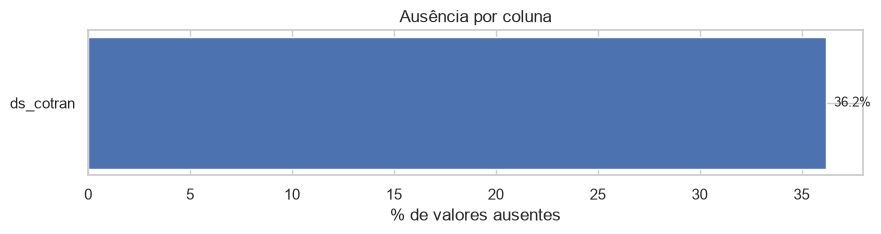

In [9]:
# Gráfico dos nulos por coluna
com_nulos = qualidade[qualidade["pct_nulos"] > 0]

if len(com_nulos):
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.32 * len(com_nulos))))
    ax.barh(com_nulos.index[::-1], com_nulos["pct_nulos"][::-1])
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Ausência por coluna")
    for i, v in enumerate(com_nulos["pct_nulos"][::-1]):
        ax.text(v + 0.4, i, f"{v}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2.1) O mapa da ausência

Cada linha do gráfico é uma linha da base; cada coluna, uma coluna. As marcas escuras são valores ausentes.

**O que procurar:** faixas horizontais contínuas. Ausência em bloco nunca é acaso — é troca de sistema, mudança de formulário ou falha de carga em um período.

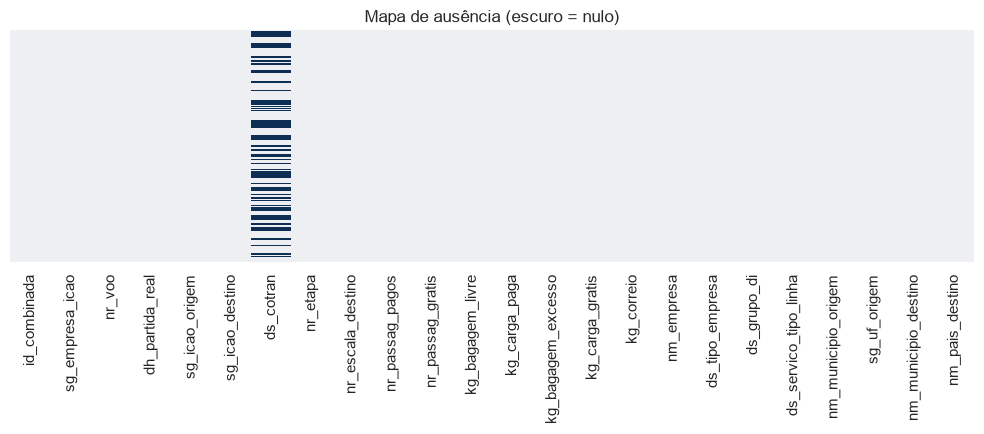

In [10]:
if df.isna().any().any():
    amostra = df if len(df) <= 500 else df.sample(500, random_state=42).sort_index()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.heatmap(amostra.isna(), cbar=False, yticklabels=False,
                cmap=["#EDEFF2", "#0F2E54"], ax=ax)
    ax.set_title("Mapa de ausência (escuro = nulo)")
    plt.tight_layout()
    plt.show()
else:
    print("Base sem valores ausentes — nada a mapear.")

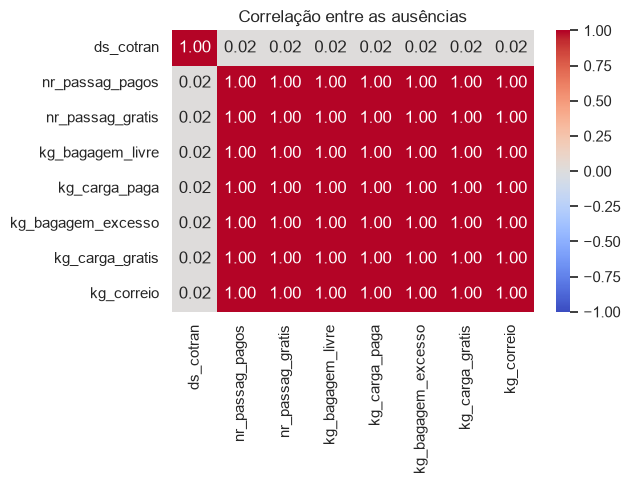

Valores próximos de 1 indicam colunas que faltam sempre juntas —
sinal de que vêm da mesma origem, que falhou.


In [11]:
# Colunas que costumam faltar juntas
nulos_bin = df.isna()
nulos_bin = nulos_bin.loc[:, nulos_bin.any()]

if nulos_bin.shape[1] >= 2:
    co = nulos_bin.corr()
    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.heatmap(co, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlação entre as ausências")
    plt.tight_layout()
    plt.show()
    print("Valores próximos de 1 indicam colunas que faltam sempre juntas —")
    print("sinal de que vêm da mesma origem, que falhou.")
else:
    print("Menos de duas colunas com ausência — correlação não se aplica.")

## 2.2) Nulos disfarçados

O `isna()` só enxerga o que foi reconhecido como ausente na leitura. O resto está disfarçado de valor.

In [12]:
SUSPEITOS_TEXTO = {"", " ", "-", "--", "n/a", "na", "nao informado",
                   "não informado", "sem dado", "null", "none", "nan",
                   "?", "xx", "zzz", "000", "999", "9999", "sem informacao"}

achados = []
for col in COLS_CAT:
    s = df[col].astype(str).str.strip().str.lower()
    n = s.isin(SUSPEITOS_TEXTO).sum()
    if n:
        exemplos = s[s.isin(SUSPEITOS_TEXTO)].value_counts().head(3).to_dict()
        achados.append([col, n, round(n / len(df) * 100, 1), str(exemplos)])

if achados:
    print("NULOS DISFARÇADOS EM COLUNAS DE TEXTO")
    display(pd.DataFrame(achados, columns=["coluna", "qtd", "pct", "exemplos"]))
else:
    print("Nenhum valor de texto suspeito encontrado.")

Nenhum valor de texto suspeito encontrado.


In [13]:
# Sentinelas numéricas: valores repetidos em excesso nos extremos
SENTINELAS = [-1, 0, 99, 999, 9999, 99999, 999999, 99999999]

achados_num = []
for col in COLS_NUM:
    s = df[col].dropna()
    if s.empty:
        continue
    for v in SENTINELAS:
        n = (s == v).sum()
        if n and n / len(s) > 0.01:
            achados_num.append([col, v, n, round(n / len(s) * 100, 1)])

if achados_num:
    print("CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)")
    display(pd.DataFrame(achados_num, columns=["coluna", "valor", "qtd", "pct"]))
    print()
    print("Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.")
else:
    print("Nenhuma sentinela numérica evidente.")

print()
print("Mínimos e máximos — o extremo costuma denunciar:")
if COLS_NUM:
    display(df[COLS_NUM].describe().T[["min", "max"]])

CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)


,coluna,valor,qtd,pct
0,nr_passag_pagos,0,11316,31.1
1,nr_passag_gratis,0,19115,52.5
2,kg_bagagem_livre,0,22374,61.5
3,kg_carga_paga,0,18032,49.5
4,kg_bagagem_excesso,0,34327,94.3
5,kg_carga_gratis,0,33557,92.2
6,kg_correio,0,35193,96.7



Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.

Mínimos e máximos — o extremo costuma denunciar:


,min,max
nr_passag_pagos,0.0,398.0
nr_passag_gratis,0.0,260.0
kg_bagagem_livre,0.0,9343.0
kg_carga_paga,0.0,116016.0
kg_bagagem_excesso,0.0,577.0
kg_carga_gratis,-33.0,10979.0
kg_correio,0.0,5385.0


In [14]:
# Duplicatas
print(f"Linhas totalmente duplicadas: {df.duplicated().sum()}")
if GRAO:
    print(f"Duplicadas no grão {GRAO}: {df.duplicated(subset=GRAO).sum()}")

if df.duplicated().sum():
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Linhas totalmente duplicadas: 0
Duplicadas no grão ['sg_empresa_icao', 'nr_voo', 'dh_partida_real', 'sg_icao_origem', 'sg_icao_destino', 'ds_cotran']: 0


---
# 3) Univariada numérica

Centro, dispersão, forma e extremos — para cada variável numérica, de uma vez.

In [15]:
def descritiva_completa(df, cols):
    linhas = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        media, dp = s.mean(), s.std()
        linhas.append({
            "variavel": c,
            "n": len(s),
            "nulos_pct": round(df[c].isna().mean() * 100, 1),
            "media": round(media, 2),
            "mediana": round(s.median(), 2),
            "desvio": round(dp, 2),
            "cv_pct": round(dp / media * 100, 1) if media else np.nan,
            "min": round(s.min(), 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "max": round(s.max(), 2),
            "iqr": round(q3 - q1, 2),
            "assimetria": round(s.skew(), 2),
            "curtose": round(s.kurtosis(), 2),
        })
    return pd.DataFrame(linhas).set_index("variavel")


if COLS_NUM:
    desc = descritiva_completa(df, COLS_NUM)
    display(desc)
else:
    print("Nenhuma coluna numérica identificada.")

,n,nulos_pct,media,mediana,desvio,cv_pct,min,q1,q3,max,iqr,assimetria,curtose
variavel,,,,,,,,,,,,,
nr_passag_pagos,36407,0.0,121.83,103.0,116.18,95.4,0.0,0.0,234.0,398.0,234.0,0.26,-1.52
nr_passag_gratis,36407,0.0,3.65,0.0,5.73,157.1,0.0,0.0,6.0,260.0,6.0,4.79,128.20
kg_bagagem_livre,36407,0.0,754.70,0.0,1382.53,183.2,0.0,0.0,857.0,9343.0,857.0,1.89,2.66
kg_carga_paga,36407,0.0,5284.00,14.0,8762.17,165.8,0.0,0.0,8596.0,116016.0,8596.0,3.41,22.71
kg_bagagem_excesso,36407,0.0,2.32,0.0,18.56,798.7,0.0,0.0,0.0,577.0,0.0,11.96,177.88
kg_carga_gratis,36407,0.0,39.07,0.0,279.52,715.4,-33.0,0.0,0.0,10979.0,0.0,14.12,296.85
kg_correio,36407,0.0,16.13,0.0,154.05,955.1,0.0,0.0,0.0,5385.0,0.0,15.31,300.65


## 3.1) Leitura automática da forma

A regra aplicada abaixo é a da Aula 6: assimetria acima de 1 em módulo já pede mediana em vez de média.

In [16]:
if COLS_NUM:
    for c in desc.index:
        a = desc.loc[c, "assimetria"]
        k = desc.loc[c, "curtose"]
        cv = desc.loc[c, "cv_pct"]

        if abs(a) < 0.5:
            forma = "aproximadamente simétrica — a média representa bem"
        elif abs(a) < 1:
            forma = "levemente assimétrica — média e mediana ainda próximas"
        else:
            lado = "à direita" if a > 0 else "à esquerda"
            forma = f"FORTEMENTE assimétrica {lado} — use a mediana"

        cauda = " Caudas pesadas: extremos mais frequentes que o esperado." if k > 3 else ""
        disp = " Dispersão muito alta." if pd.notna(cv) and cv > 100 else ""

        print(f"{c}")
        print(f"   assimetria {a:+.2f} | curtose {k:+.2f} -> {forma}.{cauda}{disp}")
        print()

nr_passag_pagos
   assimetria +0.26 | curtose -1.52 -> aproximadamente simétrica — a média representa bem.

nr_passag_gratis
   assimetria +4.79 | curtose +128.20 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_bagagem_livre
   assimetria +1.89 | curtose +2.66 -> FORTEMENTE assimétrica à direita — use a mediana. Dispersão muito alta.

kg_carga_paga
   assimetria +3.41 | curtose +22.71 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_bagagem_excesso
   assimetria +11.96 | curtose +177.88 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_carga_gratis
   assimetria +14.12 | curtose +296.85 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_correio
 

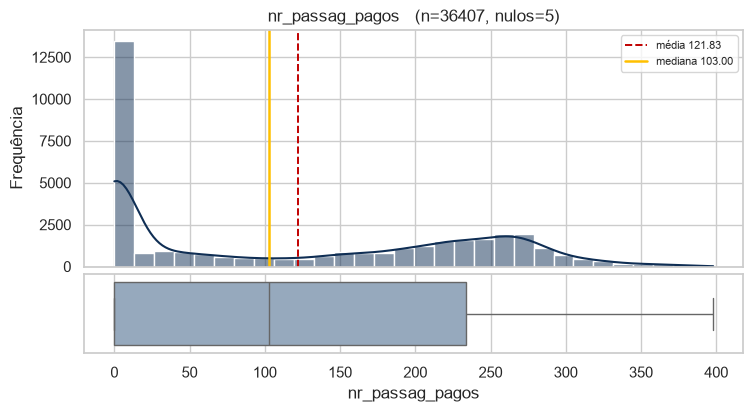

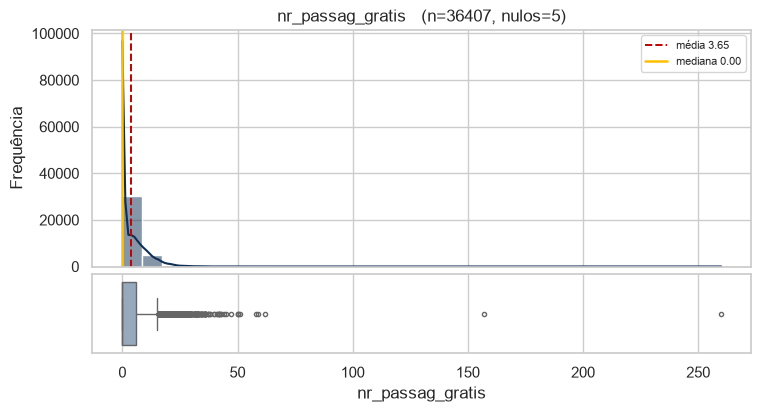

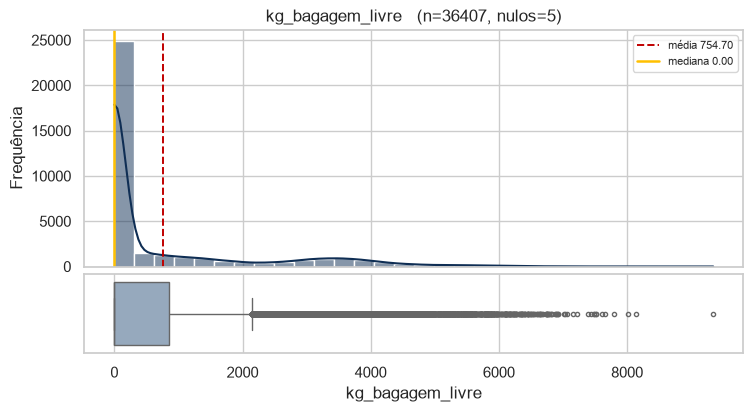

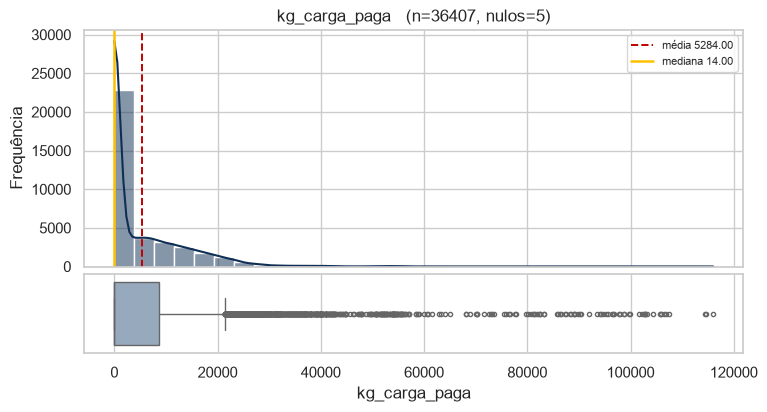

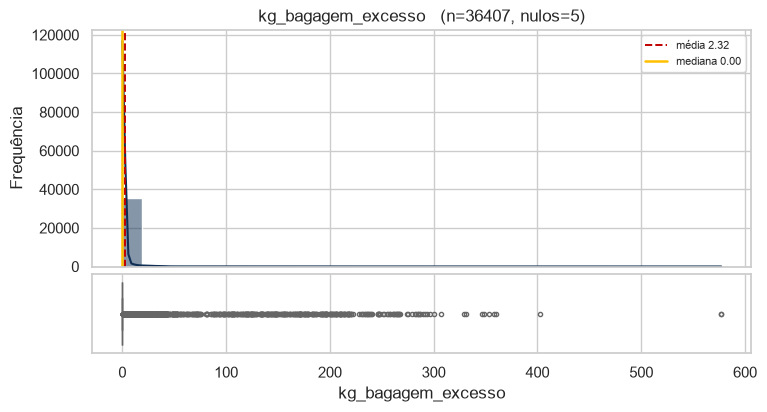

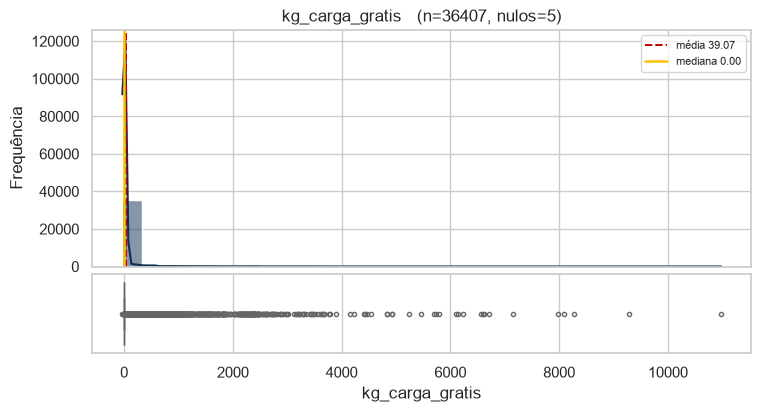

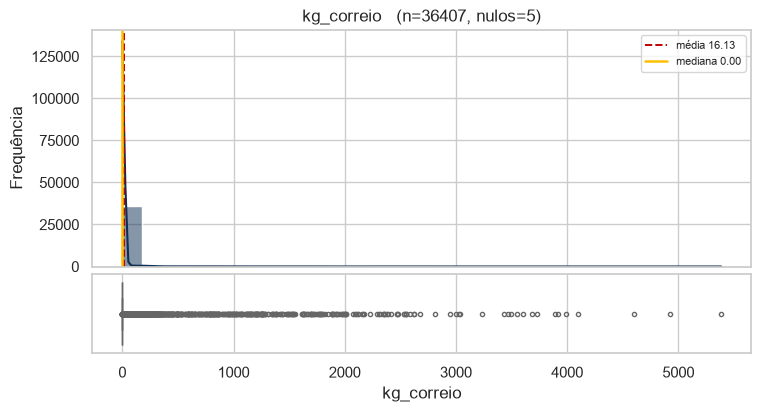

In [17]:
# Histograma + boxplot para cada variável numérica
for c in COLS_NUM:
    s = df[c].dropna()
    if s.empty or s.nunique() < 2:
        continue

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(8.5, 4.2),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    sns.histplot(s, bins=min(30, max(10, s.nunique())), kde=True, ax=ax1,
                 color="#0F2E54")
    ax1.axvline(s.mean(), color="#C00000", ls="--", lw=1.4, label=f"média {s.mean():.2f}")
    ax1.axvline(s.median(), color="#FFC000", ls="-", lw=1.8, label=f"mediana {s.median():.2f}")
    ax1.legend(fontsize=8)
    ax1.set_ylabel("Frequência")
    ax1.set_title(f"{c}   (n={len(s)}, nulos={df[c].isna().sum()})")

    sns.boxplot(x=s, ax=ax2, color="#8FA9C4", fliersize=3)
    ax2.set_xlabel(c)
    plt.tight_layout()
    plt.show()

→ **Onde média e mediana se afastam muito**, a distribuição é assimétrica e a média está sendo puxada por extremos. Reporte a mediana.

→ **Se o histograma tem dois picos**, o boxplot vai escondê-los. Sempre olhe os dois.

---
# 4) Univariada categórica

In [18]:
if COLS_CAT:
    card = pd.DataFrame({
        "distintos": df[COLS_CAT].nunique(dropna=True),
        "nulos_pct": (df[COLS_CAT].isna().mean() * 100).round(1),
        "mais_frequente": [df[c].mode().iloc[0] if not df[c].mode().empty else None
                           for c in COLS_CAT],
        "freq_do_top_pct": [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1)
                            if df[c].notna().any() else np.nan for c in COLS_CAT],
    }).sort_values("distintos", ascending=False)

    card["leitura"] = np.select(
        [card["distintos"] <= 10, card["distintos"] <= 30, card["distintos"] <= 100],
        ["barras simples", "barras horizontais ordenadas", "top N + Outros"],
        default="cardinalidade muito alta: identificador ou texto livre?")
    display(card)
else:
    print("Nenhuma coluna categórica identificada.")

,distintos,nulos_pct,mais_frequente,freq_do_top_pct,leitura
nm_municipio_destino,46,0.0,"MIAMI, FLORIDA",36.8,top N + Outros
nm_empresa,39,0.0,TAM LINHAS AÉREAS S.A.,31.4,top N + Outros
nm_municipio_origem,18,0.0,GUARULHOS,53.9,barras horizontais ordenadas
sg_uf_origem,13,0.0,SP,68.3,barras horizontais ordenadas
ds_tipo_empresa,4,0.0,ESTRANGEIRA REGULAR,36.0,barras simples
ds_cotran,3,36.2,DESEMBARQUE,37.9,barras simples
ds_grupo_di,3,0.0,REGULAR,90.2,barras simples
ds_servico_tipo_linha,3,0.0,PASSAGEIRO,56.2,barras simples
nm_pais_destino,3,0.0,ESTADOS UNIDOS DA AMÉRICA,89.0,barras simples


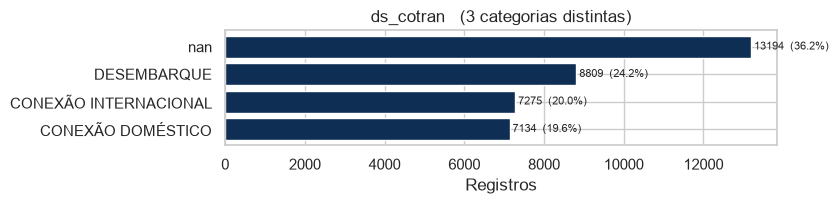

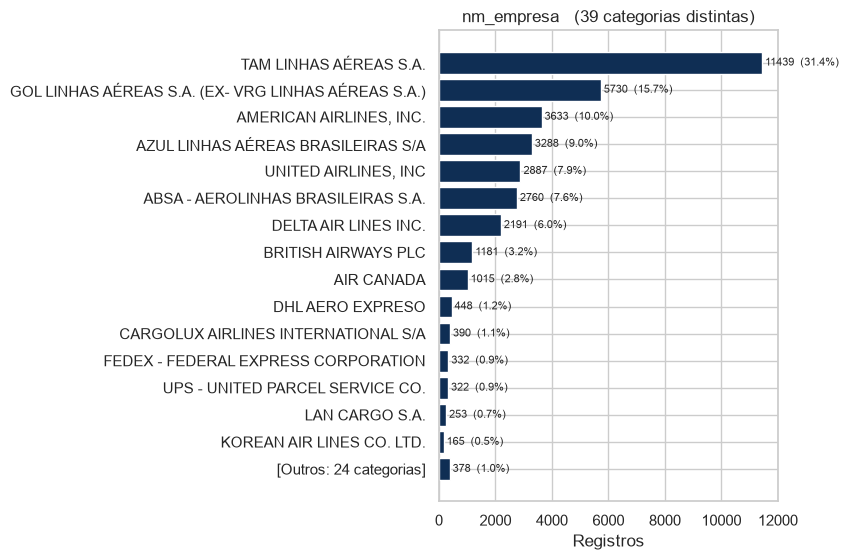

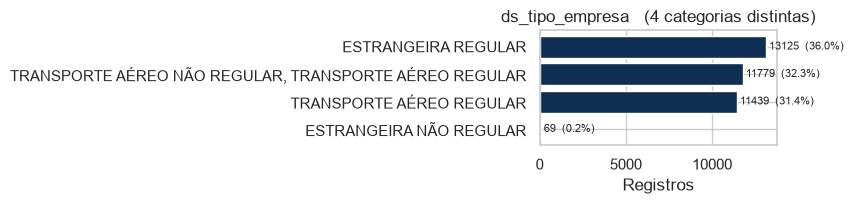

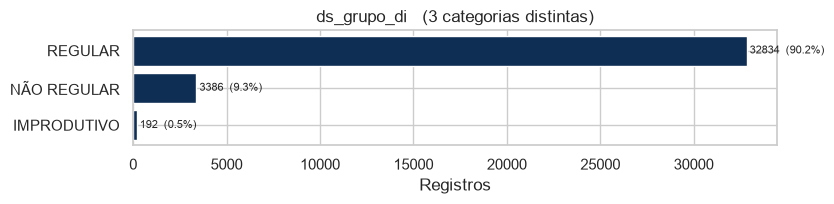

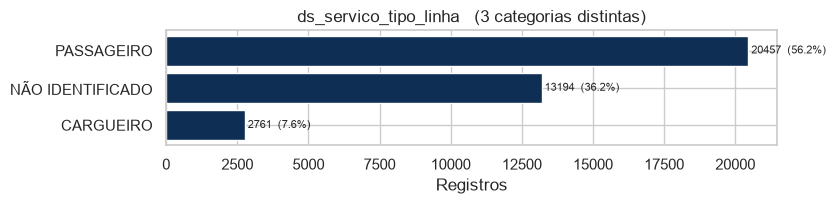

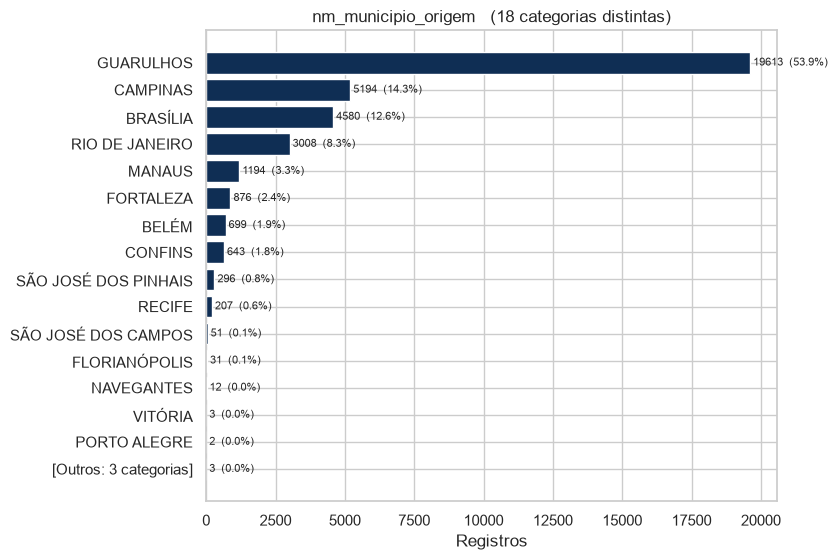

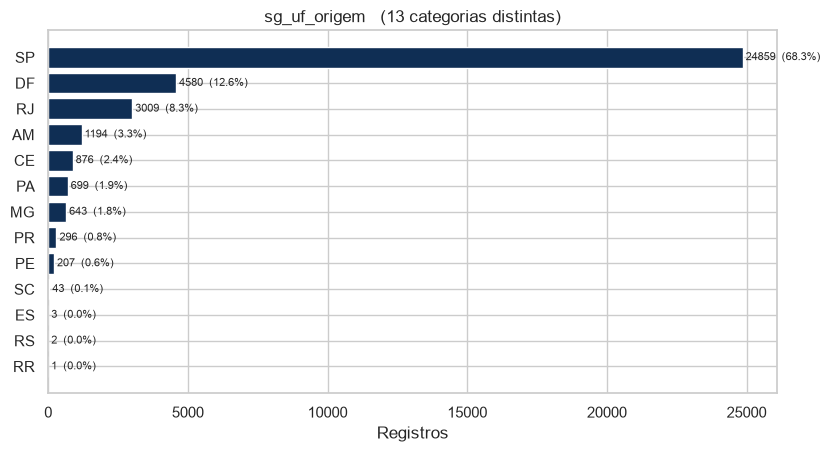

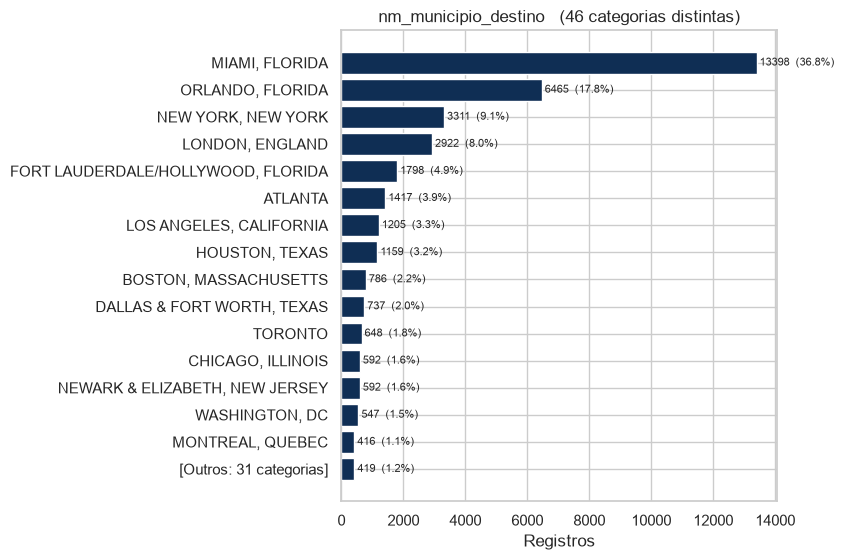

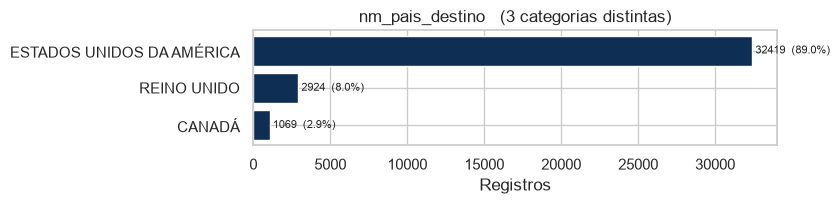

In [19]:
for c in COLS_CAT:
    vc = df[c].value_counts(dropna=False)
    if vc.empty:
        continue

    total_cat = df[c].nunique(dropna=True)
    if total_cat > MAX_CATEGORIAS:
        principais = vc.head(MAX_CATEGORIAS)
        outros = vc.iloc[MAX_CATEGORIAS:].sum()
        n_outros = len(vc) - MAX_CATEGORIAS
        principais = pd.concat([principais,
                                pd.Series({f"[Outros: {n_outros} categorias]": outros})])
    else:
        principais = vc

    fig, ax = plt.subplots(figsize=(8.5, max(2.2, 0.36 * len(principais))))
    ax.barh([str(i) for i in principais.index][::-1], principais.values[::-1],
            color="#0F2E54")
    ax.set_title(f"{c}   ({total_cat} categorias distintas)")
    ax.set_xlabel("Registros")
    for i, v in enumerate(principais.values[::-1]):
        ax.text(v, i, f" {v}  ({v/len(df)*100:.1f}%)", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

→ Categorias que aparecem escritas de formas diferentes (`SP`, `sp`, `São Paulo`) são o mesmo valor para o negócio e valores distintos para o Python. Se você vir isso aqui, volte à canonicalização da Aula 4 antes de prosseguir.

---
# 5) Outliers

Os três métodos vistos na Aula 6, aplicados lado a lado. Onde eles discordam, a decisão é sua — e precisa ser justificada.

In [20]:
def detecta_outliers(s):
    s = s.dropna()
    if len(s) < 4 or s.nunique() < 3:
        return None

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf) | (s > lim_sup)).sum()

    dp = s.std()
    n_z = (abs(s - s.mean()) > 3 * dp).sum() if dp else 0

    mad = (s - s.median()).abs().median()
    n_zmod = (0.6745 * (s - s.median()).abs() / mad > 3.5).sum() if mad else 0

    return {
        "n": len(s),
        "lim_inf_iqr": round(lim_inf, 2),
        "lim_sup_iqr": round(lim_sup, 2),
        "outliers_iqr": n_iqr,
        "pct_iqr": round(n_iqr / len(s) * 100, 1),
        "outliers_z3": n_z,
        "outliers_zmod": n_zmod,
    }


linhas = []
for c in COLS_NUM:
    r = detecta_outliers(df[c])
    if r:
        linhas.append({"variavel": c, **r})

if linhas:
    display(pd.DataFrame(linhas).set_index("variavel"))
    print("Onde os três métodos discordam muito, a distribuição não é normal —")
    print("e o IQR costuma ser a leitura mais confiável.")
else:
    print("Nenhuma variável numérica com dados suficientes para detecção.")

,n,lim_inf_iqr,lim_sup_iqr,outliers_iqr,pct_iqr,outliers_z3,outliers_zmod
variavel,,,,,,,
nr_passag_pagos,36407,-351.0,585.0,0,0.0,0,0
nr_passag_gratis,36407,-9.0,15.0,1659,4.6,601,0
kg_bagagem_livre,36407,-1285.5,2142.5,5809,16.0,626,0
kg_carga_paga,36407,-12894.0,21490.0,1705,4.7,453,17916
kg_bagagem_excesso,36407,0.0,0.0,2080,5.7,369,0
kg_carga_gratis,36407,0.0,0.0,2850,7.8,476,0
kg_correio,36407,0.0,0.0,1214,3.3,335,0


Onde os três métodos discordam muito, a distribuição não é normal —
e o IQR costuma ser a leitura mais confiável.


In [21]:
# As linhas extremas de cada variável, para inspeção manual
for c in COLS_NUM:
    s = df[c].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    fora = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)]
    if len(fora):
        print(f"\n{'='*55}\n{c}: {len(fora)} candidatos a outlier\n{'='*55}")
        display(fora.nlargest(min(5, len(fora)), c).head())


nr_passag_gratis: 1659 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino
8192,95635669,DAL,268,2025-05-23 10:04:00,SBGR,KATL,NaN,1,2,9.0,260.0,0.0,9740.0,0.0,0.0,0.0,DELTA AIR LINES INC.,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,ATLANTA,ESTADOS UNIDOS DA AMÉRICA
23498,102279515,DAL,9906,2026-01-05 23:57:00,SBGL,KATL,NaN,1,2,122.0,157.0,0.0,0.0,0.0,0.0,0.0,DELTA AIR LINES INC.,ESTRANGEIRA REGULAR,NÃO REGULAR,NÃO IDENTIFICADO,RIO DE JANEIRO,RJ,ATLANTA,ESTADOS UNIDOS DA AMÉRICA
425,93636428,UAL,3032,2025-01-14 22:10:00,SBGR,KIAD,NaN,1,2,91.0,62.0,0.0,7768.0,0.0,0.0,0.0,"UNITED AIRLINES, INC",ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,"WASHINGTON, DC",ESTADOS UNIDOS DA AMÉRICA
6406,95480323,DAL,268,2025-04-01 10:00:00,SBGR,KATL,NaN,1,2,171.0,59.0,0.0,6662.0,0.0,0.0,0.0,DELTA AIR LINES INC.,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,ATLANTA,ESTADOS UNIDOS DA AMÉRICA
30402,105533366,UAL,3017,2026-04-11 23:31:00,SBGR,KEWR,NaN,1,2,165.0,58.0,0.0,4124.0,0.0,0.0,0.0,"UNITED AIRLINES, INC",ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,"NEWARK & ELIZABETH, NEW JERSEY",ESTADOS UNIDOS DA AMÉRICA



kg_bagagem_livre: 5809 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino
20215,101186543,TAM,8084,2025-11-07 23:55:00,SBGR,EGLL,DESEMBARQUE,1,2,324.0,1.0,9343.0,6385.0,0.0,0.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"LONDON, ENGLAND",REINO UNIDO
15518,98760608,TAM,8084,2025-08-31 23:56:00,SBGR,EGLL,DESEMBARQUE,1,2,395.0,1.0,8134.0,19976.0,0.0,0.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"LONDON, ENGLAND",REINO UNIDO
14955,98746085,TAM,8084,2025-08-26 00:04:00,SBGR,EGLL,DESEMBARQUE,1,2,364.0,0.0,8020.0,22331.0,0.0,0.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"LONDON, ENGLAND",REINO UNIDO
24090,102667465,TAM,8084,2026-01-18 01:21:00,SBGR,EGLL,DESEMBARQUE,1,2,379.0,3.0,7796.0,14831.0,0.0,0.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"LONDON, ENGLAND",REINO UNIDO
15497,98758179,TAM,8084,2025-08-30 23:48:00,SBGR,EGLL,DESEMBARQUE,1,2,373.0,3.0,7654.0,14475.0,0.0,0.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"LONDON, ENGLAND",REINO UNIDO



kg_carga_paga: 1705 candidatos a outlier


...

,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino
7952,95346375,GLO,7748,2025-04-03 10:06:00,SBBR,KMIA,DESEMBARQUE,1,2,122.0,4.0,1839.0,0.0,577.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,BRASÍLIA,DF,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
13054,98164627,GLO,7634,2025-07-30 14:04:00,SBEG,KMIA,DESEMBARQUE,1,2,114.0,0.0,1094.0,0.0,577.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,MANAUS,AM,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
25247,103019547,AZU,8704,2026-01-26 23:22:00,SBKP,KFLL,DESEMBARQUE,1,2,262.0,0.0,4286.0,10590.0,402.0,0.0,0.0,AZUL LINHAS AÉREAS BRASILEIRAS S/A,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,CAMPINAS,SP,"FORT LAUDERDALE/HOLLYWOOD, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
25192,103007254,AZU,8704,2026-01-18 01:14:00,SBKP,KFLL,DESEMBARQUE,1,2,257.0,4.0,4053.0,5236.0,360.0,43.0,0.0,AZUL LINHAS AÉREAS BRASILEIRAS S/A,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,CAMPINAS,SP,"FORT LAUDERDALE/HOLLYWOOD, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
25149,102998860,AZU,8704,2026-01-11 23:13:00,SBKP,KFLL,DESEMBARQUE,1,2,288.0,0.0,4577.0,15672.0,358.0,0.0,0.0,AZUL LINHAS AÉREAS BRASILEIRAS S/A,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,CAMPINAS,SP,"FORT LAUDERDALE/HOLLYWOOD, FLORIDA",ESTADOS UNIDOS DA AMÉRICA



kg_carga_gratis: 2850 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino
16712,99523766,TAM,8194,2025-09-22 11:14:00,SBGR,KMIA,DESEMBARQUE,1,2,238.0,5.0,2784.0,0.0,0.0,10979.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
3382,94169569,TAM,8194,2025-02-25 10:50:00,SBGR,KMIA,DESEMBARQUE,1,2,363.0,13.0,4531.0,8878.0,0.0,9281.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
16694,99521309,TAM,8190,2025-09-21 23:46:00,SBGR,KMIA,DESEMBARQUE,1,2,318.0,4.0,4015.0,4709.0,0.0,8281.0,923.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
2607,94046438,UAL,63,2025-02-25 22:13:00,SBGR,KIAH,NaN,1,2,234.0,19.0,0.0,12341.0,0.0,8086.0,0.0,"UNITED AIRLINES, INC",ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,"HOUSTON, TEXAS",ESTADOS UNIDOS DA AMÉRICA
24231,102683182,TAM,8194,2026-01-23 10:15:00,SBGR,KMIA,DESEMBARQUE,1,2,339.0,21.0,4793.0,6946.0,0.0,7985.0,0.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA



kg_correio: 1214 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino
8213,95635723,DAL,104,2025-05-03 22:46:00,SBGR,KATL,NaN,1,2,277.0,5.0,0.0,4943.0,0.0,0.0,5385.0,DELTA AIR LINES INC.,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,ATLANTA,ESTADOS UNIDOS DA AMÉRICA
6557,95401293,AAL,950,2025-04-15 22:15:00,SBGR,KJFK,NaN,1,2,278.0,1.0,0.0,992.0,0.0,0.0,4923.0,"AMERICAN AIRLINES, INC.",ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,"NEW YORK, NEW YORK",ESTADOS UNIDOS DA AMÉRICA
30034,105295387,TAM,8190,2026-04-16 23:42:00,SBGR,KMIA,DESEMBARQUE,1,2,325.0,6.0,3414.0,20829.0,0.0,0.0,4601.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
29962,105288550,TAM,8194,2026-04-05 10:25:00,SBGR,KMIA,DESEMBARQUE,1,2,265.0,8.0,3437.0,15820.0,0.0,400.0,4099.0,TAM LINHAS AÉREAS S.A.,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA
9451,95707470,AAL,950,2025-05-22 22:19:00,SBGR,KJFK,NaN,1,2,246.0,0.0,0.0,4013.0,0.0,0.0,3988.0,"AMERICAN AIRLINES, INC.",ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,"NEW YORK, NEW YORK",ESTADOS UNIDOS DA AMÉRICA


→ Para cada candidato, responda a pergunta da Aula 6: **erro, evento raro ou subpopulação?**

- Erro → corrigir ou remover, documentando.
- Evento raro → manter, e reportar a métrica com e sem ele.
- Subpopulação → **segmentar**, não remover.

---
# 6) Séries temporais

Executa apenas se houver alguma coluna de data na base.

In [22]:
if COLS_DT:
    COL_TEMPO = COLS_DT[0]
    print(f"Coluna de tempo usada: {COL_TEMPO}")
    print(f"Período: {df[COL_TEMPO].min()}  ->  {df[COL_TEMPO].max()}")
    print(f"Registros sem data: {df[COL_TEMPO].isna().sum()}")

    tmp = df.dropna(subset=[COL_TEMPO]).set_index(COL_TEMPO).sort_index()
    dias = (tmp.index.max() - tmp.index.min()).days
    freq = "D" if dias <= 90 else ("W" if dias <= 730 else "MS")
    rotulo = {"D": "dia", "W": "semana", "MS": "mês"}[freq]
    print(f"Amplitude: {dias} dias -> agregando por {rotulo}")
else:
    print("Nenhuma coluna de data identificada. Seção 6 ignorada.")
    print("Se a sua base tem datas, informe-as em COLS_DATA na configuração.")

Coluna de tempo usada: dh_partida_real
Período: 2025-01-01 00:20:00  ->  2026-08-01 00:08:00
Registros sem data: 0
Amplitude: 576 dias -> agregando por semana


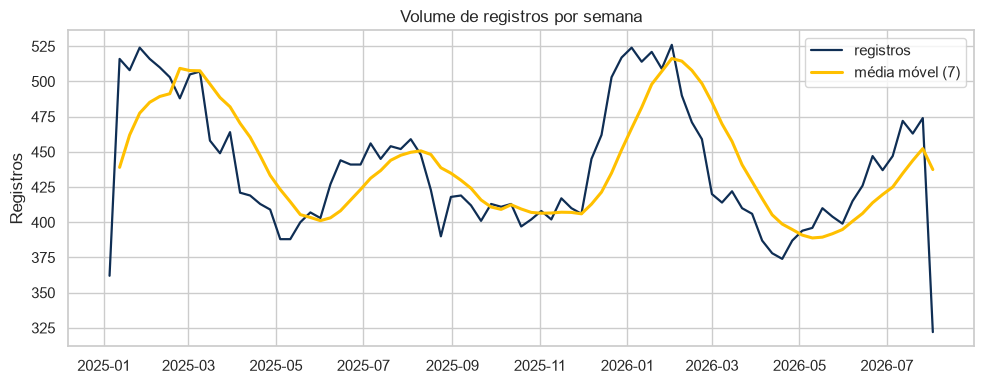

Procure: degraus (troca de sistema), buracos (falha de carga)
e o último período, que costuma estar incompleto.


In [23]:
if COLS_DT:
    volume = tmp.resample(freq).size()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(volume.index, volume.values, lw=1.6, color="#0F2E54", label="registros")
    if len(volume) >= 5:
        jan = max(3, min(7, len(volume) // 3))
        ax.plot(volume.index, volume.rolling(jan, min_periods=2).mean(),
                lw=2.2, color="#FFC000", label=f"média móvel ({jan})")
    ax.set_title(f"Volume de registros por {rotulo}")
    ax.set_ylabel("Registros")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Procure: degraus (troca de sistema), buracos (falha de carga)")
    print("e o último período, que costuma estar incompleto.")

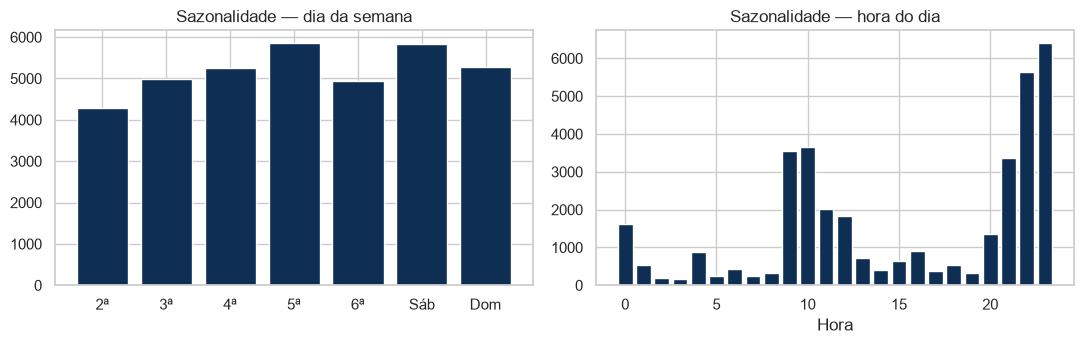

In [24]:
if COLS_DT:
    dias_pt = {"Monday": "2ª", "Tuesday": "3ª", "Wednesday": "4ª", "Thursday": "5ª",
               "Friday": "6ª", "Saturday": "Sáb", "Sunday": "Dom"}
    ordem = ["2ª", "3ª", "4ª", "5ª", "6ª", "Sáb", "Dom"]

    d = df.dropna(subset=[COL_TEMPO]).copy()
    d["_dia"] = d[COL_TEMPO].dt.day_name().map(dias_pt)
    d["_hora"] = d[COL_TEMPO].dt.hour

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    por_dia = d["_dia"].value_counts().reindex(ordem).fillna(0)
    axes[0].bar(por_dia.index, por_dia.values, color="#0F2E54")
    axes[0].set_title("Sazonalidade — dia da semana")

    if d["_hora"].nunique() > 1:
        por_hora = d["_hora"].value_counts().sort_index()
        axes[1].bar(por_hora.index, por_hora.values, color="#0F2E54")
        axes[1].set_title("Sazonalidade — hora do dia")
        axes[1].set_xlabel("Hora")
    else:
        axes[1].text(0.5, 0.5, "Sem informação de hora",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

---
# 7) Bivariada

A matriz de decisão da Aula 6 aplicada automaticamente: para cada par relevante, o gráfico correspondente ao par de tipos.

Pares numéricos com maior associação (Spearman, em módulo):


spearman_abs
nr_passag_pagos  nr_passag_gratis         0.757
                 kg_carga_paga            0.546
nr_passag_gratis kg_carga_paga            0.516

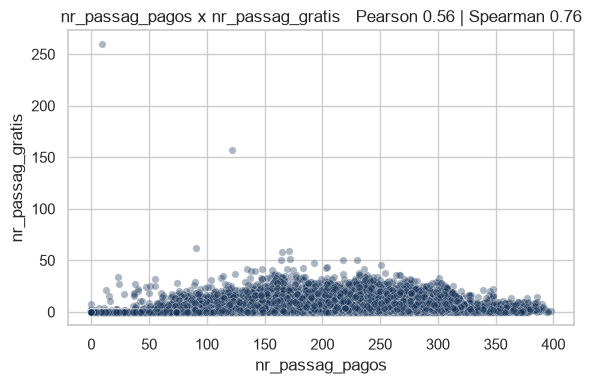

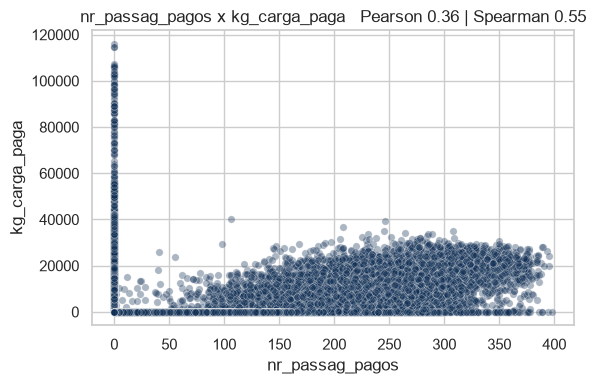

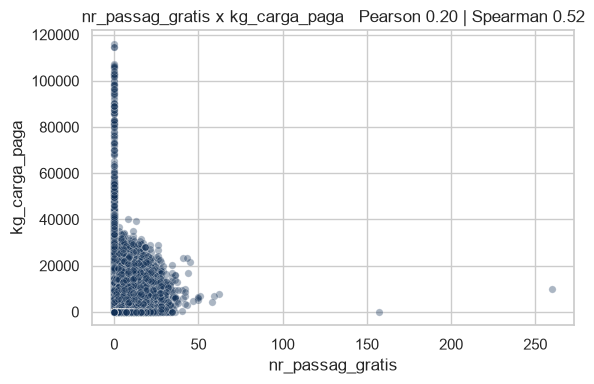

In [25]:
# Numérica x Numérica — dispersão dos pares mais correlacionados
if len(COLS_NUM) >= 2:
    corr_s = df[COLS_NUM].corr(method="spearman").abs()
    pares = (corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool))
                   .stack().sort_values(ascending=False))
    top = pares.head(3)

    print("Pares numéricos com maior associação (Spearman, em módulo):")
    display(top.round(3).to_frame("spearman_abs"))

    for (a, b), _ in top.items():
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.scatterplot(data=df, x=a, y=b, alpha=0.35, s=28,
                        color="#0F2E54", ax=ax)
        p = df[[a, b]].corr().iloc[0, 1]
        sp = df[[a, b]].corr(method="spearman").iloc[0, 1]
        ax.set_title(f"{a} x {b}   Pearson {p:.2f} | Spearman {sp:.2f}")
        plt.tight_layout()
        plt.show()
else:
    print("Menos de duas variáveis numéricas — dispersão não se aplica.")

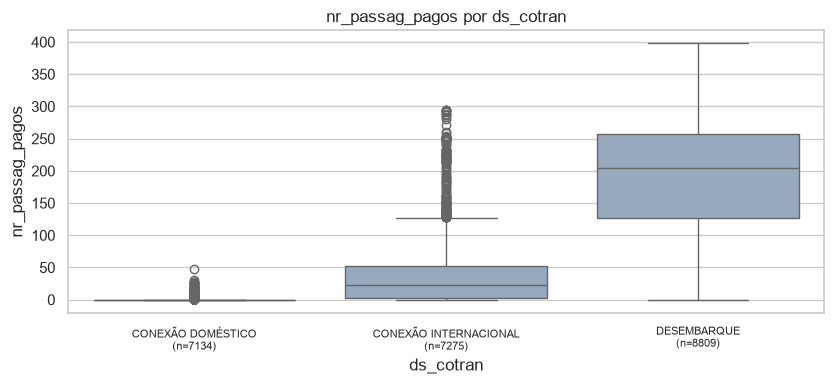

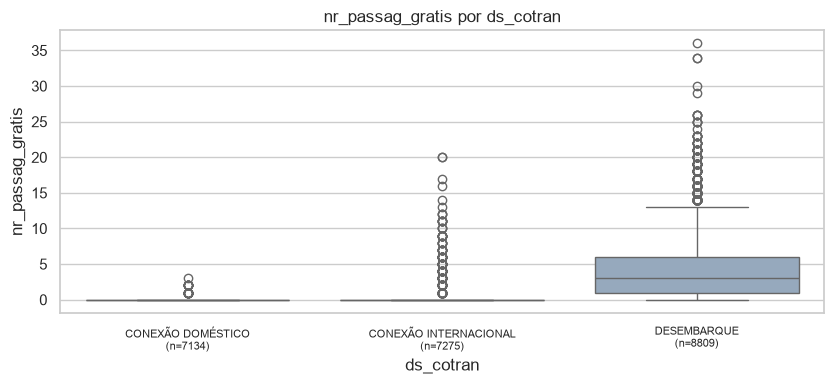

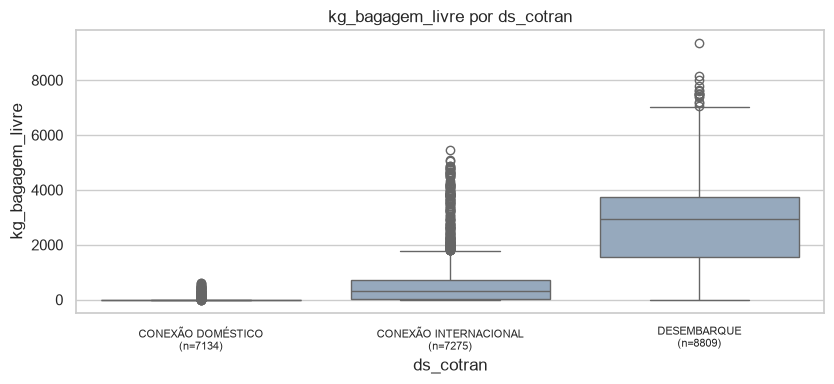

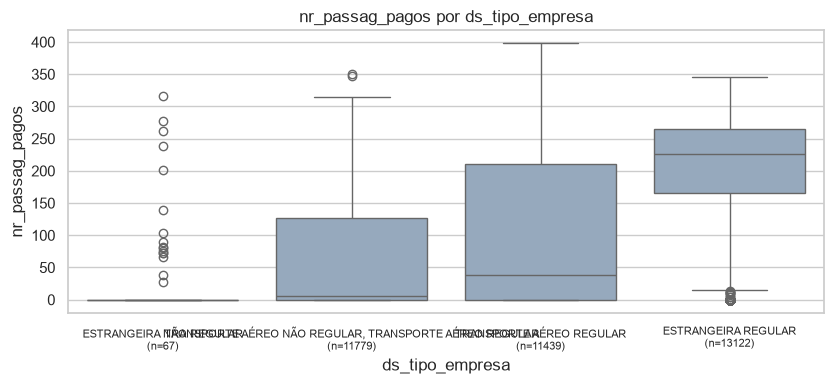

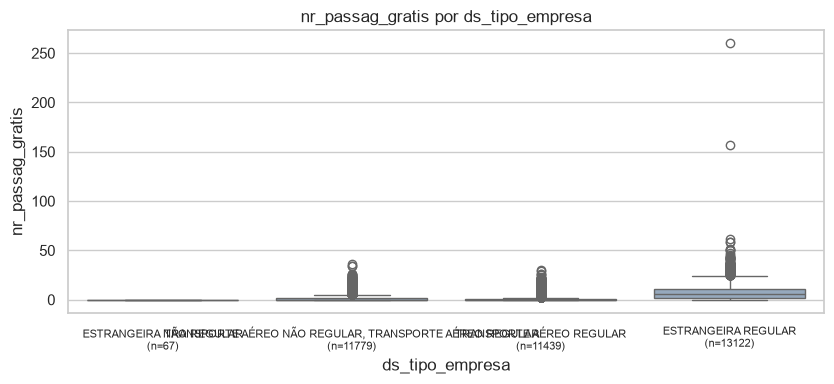

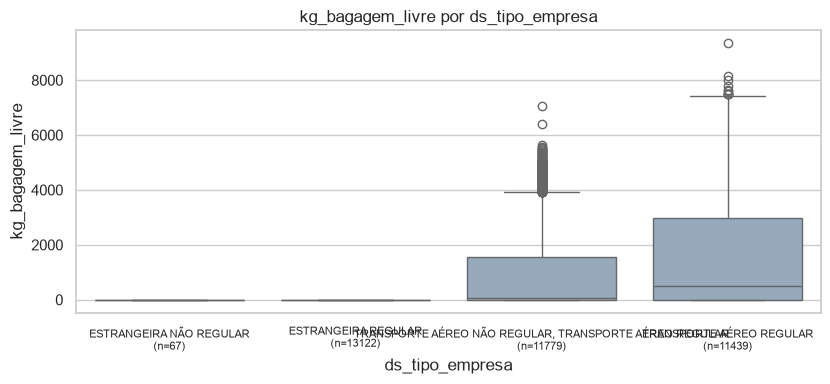

In [26]:
# Categórica x Numérica — boxplot por categoria
pares_feitos = 0
for cat in COLS_CAT:
    if not (2 <= df[cat].nunique() <= 12):
        continue
    for num in COLS_NUM[:3]:
        fig, ax = plt.subplots(figsize=(8.5, 4))
        ordem_cat = df.groupby(cat)[num].median().sort_values().index
        sns.boxplot(data=df, x=cat, y=num, order=ordem_cat,
                    color="#8FA9C4", ax=ax)
        ns = df.groupby(cat)[num].count().reindex(ordem_cat)
        ax.set_xticklabels([f"{c}\n(n={ns[c]})" for c in ordem_cat], fontsize=8)
        ax.set_title(f"{num} por {cat}")
        plt.tight_layout()
        plt.show()
        pares_feitos += 1
        if pares_feitos >= 6:
            break
    if pares_feitos >= 6:
        break

if pares_feitos == 0:
    print("Nenhum par categórica x numérica adequado encontrado.")

Contagem — ds_cotran x ds_tipo_empresa


ds_tipo_empresa,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",TRANSPORTE AÉREO REGULAR
ds_cotran,,
CONEXÃO DOMÉSTICO,3321,3813
CONEXÃO INTERNACIONAL,3462,3813
DESEMBARQUE,4996,3813



Proporção por linha (o que se deve ler)


ds_tipo_empresa,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",TRANSPORTE AÉREO REGULAR
ds_cotran,,
CONEXÃO DOMÉSTICO,46.6,53.4
CONEXÃO INTERNACIONAL,47.6,52.4
DESEMBARQUE,56.7,43.3


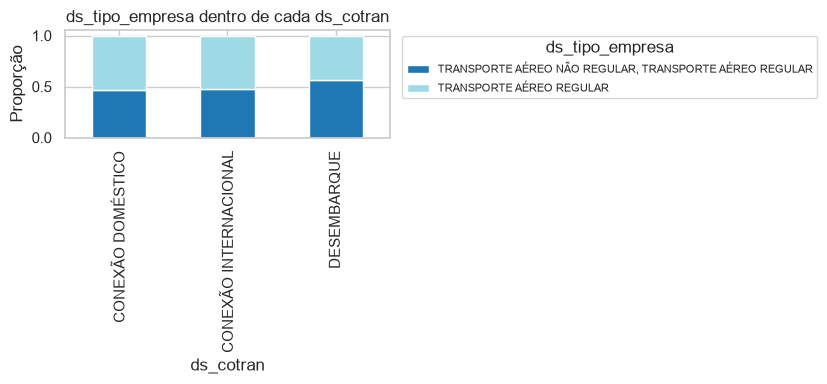

In [27]:
# Categórica x Categórica — proporção por linha, nunca contagem
cats_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 10]

if len(cats_ok) >= 2:
    a, b = cats_ok[0], cats_ok[1]
    ct_n = pd.crosstab(df[a], df[b])
    ct_p = pd.crosstab(df[a], df[b], normalize="index")

    print(f"Contagem — {a} x {b}")
    display(ct_n)
    print(f"\nProporção por linha (o que se deve ler)")
    display((ct_p * 100).round(1))

    fig, ax = plt.subplots(figsize=(8.5, 4))
    ct_p.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_ylabel("Proporção")
    ax.set_title(f"{b} dentro de cada {a}")
    ax.legend(title=b, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Menos de duas categóricas adequadas para tabela de contingência.")

---
# 8) Correlação

Pearson mede relação **linear**. Spearman mede relação **monotônica**, sobre os postos. Quando os dois discordam, existe relação — só não é uma reta.

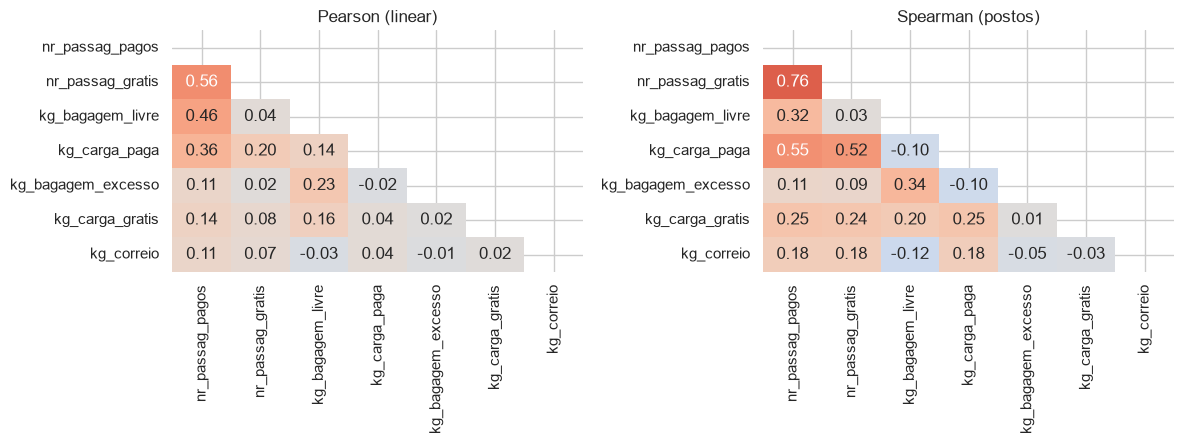

Pares em que Pearson e Spearman discordam (diferença > 0,15):


diferenca
nr_passag_gratis kg_carga_paga         0.317
kg_bagagem_livre kg_carga_paga         0.241
kg_carga_paga    kg_carga_gratis       0.206
nr_passag_pagos  nr_passag_gratis      0.198
                 kg_carga_paga         0.190
nr_passag_gratis kg_carga_gratis       0.156

Relação provavelmente não linear, ou influenciada por outliers.
Olhe o gráfico de dispersão antes de concluir qualquer coisa.


In [28]:
if len(COLS_NUM) >= 2:
    p = df[COLS_NUM].corr(method="pearson")
    s = df[COLS_NUM].corr(method="spearman")
    mask = np.triu(np.ones_like(p, dtype=bool))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    sns.heatmap(p, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[0], cbar=False)
    axes[0].set_title("Pearson (linear)")
    sns.heatmap(s, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[1], cbar=False)
    axes[1].set_title("Spearman (postos)")
    plt.tight_layout()
    plt.show()

    dif = (s - p).abs()
    dif = dif.where(np.triu(np.ones(dif.shape), k=1).astype(bool)).stack()
    fortes = dif[dif > 0.15].sort_values(ascending=False)
    if len(fortes):
        print("Pares em que Pearson e Spearman discordam (diferença > 0,15):")
        display(fortes.round(3).to_frame("diferenca"))
        print("Relação provavelmente não linear, ou influenciada por outliers.")
        print("Olhe o gráfico de dispersão antes de concluir qualquer coisa.")
    else:
        print("Pearson e Spearman concordam em todos os pares.")
else:
    print("Menos de duas variáveis numéricas.")

> **Lembrete de Anscombe:** nenhum número desta matriz entra no relatório sem o gráfico de dispersão correspondente ao lado.

---
# 9) Segmentação

A métrica principal por cada dimensão categórica — **sempre com o n ao lado**, como visto na Aula 6.

In [29]:
ALVO = COL_ALVO if COL_ALVO in df.columns else (COLS_NUM[0] if COLS_NUM else None)

if ALVO is None:
    print("Nenhuma variável-alvo disponível. Defina COL_ALVO na configuração.")
elif ALVO in COLS_NUM:
    print(f"Variável analisada: {ALVO} (numérica)\n")
    for cat in COLS_CAT:
        if not (2 <= df[cat].nunique() <= 20):
            continue
        seg = (df.groupby(cat)[ALVO]
                 .agg(n="size", media="mean", mediana="median", desvio="std")
                 .round(2)
                 .sort_values("media", ascending=False))
        seg["confiavel"] = np.where(seg["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} ---")
        display(seg)
else:
    print(f"Variável analisada: {ALVO} (categórica)\n")
    for cat in COLS_CAT:
        if cat == ALVO or not (2 <= df[cat].nunique() <= 20):
            continue
        ct = pd.crosstab(df[cat], df[ALVO], normalize="index").round(3) * 100
        ct["n"] = df[cat].value_counts()
        ct["confiavel"] = np.where(ct["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} (% por linha) ---")
        display(ct)

Variável analisada: nm_pais_destino (categórica)

--- nm_pais_destino por ds_cotran (% por linha) ---


nm_pais_destino,ESTADOS UNIDOS DA AMÉRICA,REINO UNIDO,n,confiavel
ds_cotran,,,,
CONEXÃO DOMÉSTICO,91.9,8.1,7134,sim
CONEXÃO INTERNACIONAL,92.0,8.0,7275,sim
DESEMBARQUE,93.4,6.6,8809,sim


--- nm_pais_destino por ds_tipo_empresa (% por linha) ---


nm_pais_destino,CANADÁ,ESTADOS UNIDOS DA AMÉRICA,REINO UNIDO,n,confiavel
ds_tipo_empresa,,,,,
ESTRANGEIRA NÃO REGULAR,0.0,97.1,2.9,69,sim
ESTRANGEIRA REGULAR,8.1,82.8,9.0,13125,sim
"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",0.0,100.0,0.0,11779,sim
TRANSPORTE AÉREO REGULAR,0.0,84.8,15.2,11439,sim


--- nm_pais_destino por ds_grupo_di (% por linha) ---


...

nm_pais_destino,CANADÁ,ESTADOS UNIDOS DA AMÉRICA,REINO UNIDO,n,confiavel
ds_servico_tipo_linha,,,,,
CARGUEIRO,0.0,100.0,0.0,2761,sim
NÃO IDENTIFICADO,8.1,82.9,9.0,13194,sim
PASSAGEIRO,0.0,91.5,8.5,20457,sim


--- nm_pais_destino por nm_municipio_origem (% por linha) ---


nm_pais_destino,CANADÁ,ESTADOS UNIDOS DA AMÉRICA,REINO UNIDO,n,confiavel
nm_municipio_origem,,,,,
BELÉM,0.0,100.0,0.0,699,sim
BOA VISTA,0.0,100.0,0.0,1,N BAIXO
BRASÍLIA,0.0,100.0,0.0,4580,sim
CABO FRIO,0.0,100.0,0.0,1,N BAIXO
CAMPINAS,0.0,99.9,0.1,5194,sim
CONFINS,0.0,100.0,0.0,643,sim
FLORIANÓPOLIS,0.0,100.0,0.0,31,sim
FORTALEZA,0.0,99.9,0.1,876,sim
GUARULHOS,4.9,83.1,12.0,19613,sim


--- nm_pais_destino por sg_uf_origem (% por linha) ---


nm_pais_destino,CANADÁ,ESTADOS UNIDOS DA AMÉRICA,REINO UNIDO,n,confiavel
sg_uf_origem,,,,,
AM,0.0,100.0,0.0,1194,sim
CE,0.0,99.9,0.1,876,sim
DF,0.0,100.0,0.0,4580,sim
ES,0.0,100.0,0.0,3,N BAIXO
MG,0.0,100.0,0.0,643,sim
PA,0.0,100.0,0.0,699,sim
PE,0.0,100.0,0.0,207,sim
PR,0.0,100.0,0.0,296,sim
RJ,3.3,77.7,19.0,3009,sim


→ Segmentos marcados como **N BAIXO** têm poucos registros: a métrica deles oscila muito por construção e não sustenta recomendação. Trate-os separadamente, ou agrupe.

---
# 10) Multivariada

Facetas e o teste de Simpson.

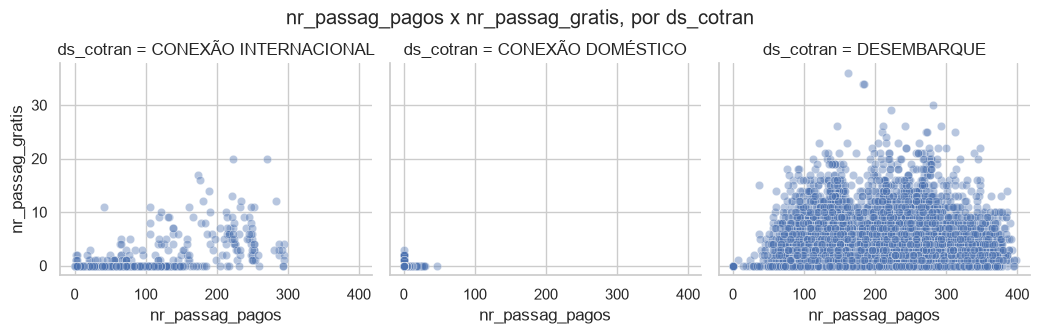

Eixos fixos em todos os painéis — é o que torna os painéis comparáveis.


In [30]:
# Facetas: a mesma relação, repetida dentro de cada valor de uma terceira variável
cats_faceta = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 4]

if cats_faceta and len(COLS_NUM) >= 2:
    faceta = cats_faceta[0]
    x, y = COLS_NUM[0], COLS_NUM[1]
    g = sns.relplot(data=df, x=x, y=y, col=faceta, kind="scatter",
                    alpha=0.4, height=3.2, aspect=1.1,
                    facet_kws={"sharex": True, "sharey": True})
    g.figure.suptitle(f"{x} x {y}, por {faceta}", y=1.04)
    plt.show()
    print("Eixos fixos em todos os painéis — é o que torna os painéis comparáveis.")
else:
    print("Sem combinação adequada para facetas.")

In [31]:
def teste_simpson(df, grupo, segmento, metrica):
    """Compara a direção da métrica no agregado e dentro de cada segmento."""
    agregado = df.groupby(grupo)[metrica].mean()
    vencedor_geral = agregado.idxmax()

    por_seg = df.groupby([segmento, grupo])[metrica].mean().unstack()
    por_seg = por_seg.dropna()
    if por_seg.empty:
        return None

    vencedores = por_seg.idxmax(axis=1)
    invertidos = vencedores[vencedores != vencedor_geral]

    margem = round(float(agregado.max() - agregado.min()), 4)

    return {
        "margem_agregado": margem,
        "agregado": agregado.round(3),
        "por_segmento": por_seg.round(3),
        "composicao": pd.crosstab(df[grupo], df[segmento], normalize="index").round(3),
        "vencedor_geral": vencedor_geral,
        "segmentos_invertidos": list(invertidos.index),
    }


grupos_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 5]

# Se o alvo for categórico binário, vira uma métrica 0/1 — bem mais informativo
df_s = df.copy()
metrica = None
if COL_ALVO in df.columns and df[COL_ALVO].nunique(dropna=True) == 2:
    niveis = sorted(df[COL_ALVO].dropna().unique())
    df_s["_taxa_alvo"] = (df_s[COL_ALVO] == niveis[-1]).astype(float)
    metrica = "_taxa_alvo"
    print(f"Métrica: proporção de '{niveis[-1]}' em {COL_ALVO}")
elif COLS_NUM:
    metrica = COLS_NUM[0]
    print(f"Métrica: {metrica}")

grupos_ok = [c for c in grupos_ok if c != COL_ALVO]

if len(grupos_ok) >= 2 and metrica:
    grupo, segmento = grupos_ok[0], grupos_ok[1]
    df = df_s
    print(f"Grupos: {grupo}   |   Segmentado por: {segmento}\n")

    r = teste_simpson(df, grupo, segmento, metrica)
    if r:
        print("No agregado:")
        display(r["agregado"])
        print("\nPor segmento:")
        display(r["por_segmento"])
        print("\nComposição de cada grupo (é aqui que o paradoxo nasce):")
        display(r["composicao"])

        if r["segmentos_invertidos"]:
            print("\n" + "!" * 60)
            print(f"ATENÇÃO: no agregado vence '{r['vencedor_geral']}',")
            print(f"mas em {r['segmentos_invertidos']} o vencedor é outro.")
            print(f"Margem no agregado: {r['margem_agregado']}")
            print("Verifique se a diferença é grande o bastante para importar.")
            print("Isto é o paradoxo de Simpson. NÃO reporte apenas o agregado.")
            print("!" * 60)
        else:
            print("\nDireção consistente entre agregado e segmentos — sem inversão.")
else:
    print("Combinação insuficiente para o teste de Simpson.")
    print("Ele exige duas categóricas de poucos níveis e uma métrica numérica.")

Métrica: nr_passag_pagos
Grupos: ds_cotran   |   Segmentado por: ds_tipo_empresa

No agregado:


ds_cotran
CONEXÃO DOMÉSTICO          0.378
CONEXÃO INTERNACIONAL     33.178
DESEMBARQUE              187.592
Name: nr_passag_pagos, dtype: float64


Por segmento:


ds_cotran,CONEXÃO DOMÉSTICO,CONEXÃO INTERNACIONAL,DESEMBARQUE
ds_tipo_empresa,,,
"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",0.803,22.886,137.837
TRANSPORTE AÉREO REGULAR,0.008,42.523,252.782



Composição de cada grupo (é aqui que o paradoxo nasce):


ds_tipo_empresa,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",TRANSPORTE AÉREO REGULAR
ds_cotran,,
CONEXÃO DOMÉSTICO,0.466,0.534
CONEXÃO INTERNACIONAL,0.476,0.524
DESEMBARQUE,0.567,0.433



Direção consistente entre agregado e segmentos — sem inversão.


→ O teste acima roda no primeiro par de categóricas encontrado. **Rode-o manualmente** para as combinações que fazem sentido no seu domínio — é o conhecimento do negócio que aponta onde procurar confundimento, não o código.

```python
r = teste_simpson(df, grupo="unidade", segmento="faixa_etaria", metrica="faltou")
```

In [32]:
r = teste_simpson(df, grupo="nm_pais_destino", segmento="ds_servico_tipo_linha", metrica="nr_passag_pagos")
display(r["agregado"], r["por_segmento"], r["composicao"])
print("Invertidos:", r["segmentos_invertidos"])

nm_pais_destino
CANADÁ                       235.433
ESTADOS UNIDOS DA AMÉRICA    113.908
REINO UNIDO                  168.207
Name: nr_passag_pagos, dtype: float64

nm_pais_destino,CANADÁ,ESTADOS UNIDOS DA AMÉRICA,REINO UNIDO
ds_servico_tipo_linha,,,
NÃO IDENTIFICADO,235.433,184.485,227.94


ds_servico_tipo_linha,CARGUEIRO,NÃO IDENTIFICADO,PASSAGEIRO
nm_pais_destino,,,
CANADÁ,0.000,1.000,0.000
ESTADOS UNIDOS DA AMÉRICA,0.085,0.337,0.577
REINO UNIDO,0.000,0.405,0.595


Invertidos: []


---
# 11) Síntese

A EDA não termina em gráficos. Termina em **achados, hipóteses e decisões**.

Preencha a célula abaixo com as suas conclusões — é este texto, e não os gráficos, que vai para o relatório do PI.

In [ ]:
SINTESE = """
ACHADOS
   1. A base mistura dois regimes de registro. ds_cotran tem 13.194 nulos (36,2%,
      relatorio_qualidade), e eles coincidem exatamente com os 13.194 registros de
      ds_servico_tipo_linha = NÃO IDENTIFICADO: nenhum nulo fora desse grupo, nenhum
      valor preenchido dentro dele. Nos registros PASSAGEIRO e CARGUEIRO, cada trecho
      se divide em até 3 linhas (desembarque, conexão doméstica, conexão
      internacional). Nos NÃO IDENTIFICADO, o trecho vem numa linha só. Por isso a 
      mediana de passageiros pagos por registro é 226 nos NÃO IDENTIFICADO e 41 nos 
      PASSAGEIRO. Sustentação: gráfico de ausência por coluna (seção 2) e
      pd.crosstab(df.ds_servico_tipo_linha, df.ds_cotran.fillna("NULO")).

   2. nr_passag_pagos é bimodal: 31,1% dos registros têm zero passageiros, e o
      restante se concentra em 200 a 250. Média 121,8, mediana 103, Q1 = 0,
      Q3 = 234, curtose -1,52 (estatistica_descritiva). A média não representa
      nenhum dos dois grupos. Os zeros vêm de voos cargueiros (2.761 registros,
      100% zero), de registros IMPRODUTIVO (192, 100% zero) e das linhas de
      conexão doméstica (média de 0,38 passageiro). Sustentação: histograma e
      boxplot de nr_passag_pagos (seção 3).

   3. A demanda tem pico em dezembro e janeiro. Passageiros pagos: jan/2025
      284.865, dez/2025 276.740, jan/2026 289.216, contra o vale de 207.270 em
      set/2025 (janeiro fica cerca de 38% acima do vale). Julho sobe pouco
      (231.051 e 228.162). O volume de registros acompanha: 2.280 e 2.307 em
      janeiro, contra 1.639 a 1.800 nos meses letivos. Sustentação: gráfico de
      volume por mês (seção 6) e soma mensal de nr_passag_pagos.

   4. Teste de Simpson (nm_pais_destino x ds_servico_tipo_linha, métrica
      nr_passag_pagos): sem inversão. CANADÁ tem a maior média de passageiros
      por registro no agregado (~235) e também lidera dentro de cada regime de
      registro. A média por registro não mede volume: em total de passageiros
      pagos, os Estados Unidos concentram 83% do fluxo.

HIPÓTESES
   1. Os dois regimes do achado 1 correspondem a formas diferentes de declaração
      à ANAC (tipo de empresa, sistema de envio ou formulário), e não a voos de
      natureza diferente. Para verificar: cruzar ds_servico_tipo_linha com
      nm_empresa e ds_tipo_empresa e com o mês (se o regime muda por empresa ou
      por data, é origem administrativa) e conferir o dicionário de dados da
      base combinada da ANAC.

   2. O pico de dezembro e janeiro é puxado pelas férias escolares e por viagens
      de lazer, e o de julho é fraco porque as férias de meio de ano são curtas.
      Para verificar: comparar com destinos não anglófonos (Portugal, Argentina)
      na mesma base. Se eles tiverem o mesmo pico, o efeito é das férias em
      geral, e não específico dos destinos de língua inglesa. O motivo da viagem
      exige outra fonte (Polícia Federal, Embratur).

DECISÕES DE TRATAMENTO
   1. Ausentes. ds_cotran nulo é estrutural (achado 1). Não imputar: recodificar
      como "NÃO DETALHADO", para não ser tratado como falha. Os 5 registros com
      todas as colunas numéricas nulas (todos NÃO IDENTIFICADO, 0,01% da base)
      são removidos, com registro do motivo, porque não carregam nenhuma medida.
      NÃO IDENTIFICADO em ds_servico_tipo_linha é mantido como categoria, e não 
      acrescentado a NA_EXTRA, porque identifica o regime de registro sem 
      detalhamento por ds_cotran.

   2. Outliers. kg_carga_gratis tem 3 valores negativos (Azul, de -3 a -33 kg):
      é erro, porque peso não pode ser negativo, então esses valores viram nulo.
      nr_passag_gratis = 260 com apenas 9 pagantes (Delta 268, 23/05/2025,
      destino ATL) é evento raro ou erro de declaração: fica na base, e as
      métricas de passageiros grátis são reportadas com e sem ele. Os zeros de
      nr_passag_pagos não são outliers, são subpopulações (cargueiro,
      improdutivo, conexão doméstica): segmentar, não remover. Em kg_bagagem_
      excesso, kg_carga_gratis e kg_correio o IQR é 0, então o método IQR marca
      como outlier qualquer valor diferente de zero. Nessas variáveis, com
      excesso de zeros, a regra de outlier não se aplica. Os valores altos de 
      kg_carga_paga vêm de voos cargueiros: subpopulação, analisada separadamente.

   3. Categorias raras. ESTRANGEIRA NÃO REGULAR (69 registros) e IMPRODUTIVO
      (192) ficam fora da análise de demanda. Das 39 empresas, as 6 maiores
      somam 88,3% dos passageiros: as demais são agrupadas em "Outras". O mês
      2026-08 (4 registros, voos do arquivo de julho que decolaram em 1º de
      agosto) sai das séries temporais porque está incompleto.

LIMITAÇÕES
   1. A base registra movimento de aeronaves, não pessoas. Não há
      nacionalidade, motivo da viagem nem destino final do passageiro. Quem faz
      conexão internacional (241.372 pagos) pode seguir para um país não
      anglófono, e quem vai aos EUA por Lisboa ou Panamá não aparece. A base
      serve como proxy de fluxo para países de língua inglesa, não como medida
      de demanda por inglês.

   2. Para 57,2% dos passageiros pagos (2.538.992 de 4.435.557, regime NÃO
      IDENTIFICADO) não é possível separar quem desembarca de quem só faz
      conexão, porque ds_cotran não é preenchido. E 19 meses dão só um ciclo
      completo de agosto a dezembro, o que não basta para separar sazonalidade
      de tendência com segurança.
"""

print(SINTESE)


ACHADOS
   1. A base mistura dois regimes de registro. ds_cotran tem 13.194 nulos (36,2%,
      relatorio_qualidade), e eles coincidem exatamente com os 13.194 registros de
      ds_servico_tipo_linha = NÃO IDENTIFICADO: nenhum nulo fora desse grupo, nenhum
      valor preenchido dentro dele. Nos registros PASSAGEIRO e CARGUEIRO, cada trecho
      se divide em até 3 linhas (desembarque, conexão doméstica, conexão
      internacional). Nos NÃO IDENTIFICADO, o trecho vem numa linha só. Por isso a 
      mediana de passageiros pagos por registro é 226 nos NÃO IDENTIFICADO e 41 nos 
      PASSAGEIRO. Sustentação: gráfico de ausência por coluna (seção 2) e
      pd.crosstab(df.ds_servico_tipo_linha, df.ds_cotran.fillna("NULO")).

   2. nr_passag_pagos é bimodal: 31,1% dos registros têm zero passageiros, e o
      restante se concentra em 200 a 250. Média 121,8, mediana 103, Q1 = 0,
      Q3 = 234, curtose -1,52 (estatistica_descritiva). A média não representa
      nenhum dos dois grupos. 

In [34]:
# Exportação da base tratada e do relatório de qualidade
df.to_csv("base_tratada.csv", index=False, encoding="utf-8-sig")
qualidade.to_csv("relatorio_qualidade.csv", encoding="utf-8-sig")

if COLS_NUM:
    desc.to_csv("estatistica_descritiva.csv", encoding="utf-8-sig")

print("Arquivos gerados:")
print("   base_tratada.csv")
print("   relatorio_qualidade.csv")
if COLS_NUM:
    print("   estatistica_descritiva.csv")

Arquivos gerados:
   base_tratada.csv
   relatorio_qualidade.csv
   estatistica_descritiva.csv


---

## Antes de entregar

- [ ] A configuração aponta para a base do seu PI, não para a base de exemplo
- [ ] A coluna `perda_pct` foi conferida: nenhuma conversão perdeu dados em silêncio
- [ ] Os nulos disfarçados encontrados foram acrescentados a `NA_EXTRA` e o notebook foi rodado de novo
- [ ] Cada candidato a outlier foi classificado: erro, evento raro ou subpopulação
- [ ] O teste de Simpson foi rodado nas combinações que fazem sentido no seu domínio
- [ ] A célula de síntese está preenchida

---

*SPTech School — Análise de Dados — Prof. Rodrigo Fernandes*